In [25]:
import numpy as np
import tensorflow as tf
import tensorflow.keras as K
from tensorflow.keras.layers import Input, Dense, Reshape, Flatten, Dropout, Multiply, Embedding, Conv2D, Conv2DTranspose, LeakyReLU, BatchNormalization, Activation
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import RMSprop
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt
from skimage.transform import resize
from tensorflow.keras import layers, Model, optimizers
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, average_precision_score
import scipy.io
import itertools
import time
import shutil
import os


In [26]:
def wasserstein_loss(y_true, y_pred):
    return tf.reduce_mean(y_true * y_pred)
class WGAN:
    def __init__(self, output_dir='wgan_generated_output', model_dir='wgan_saved_models'):
        # Image dimensions
        self.img_rows = 32
        self.img_cols = 32
        self.channels = 3
        self.img_shape = (self.img_rows, self.img_cols, self.channels)

        # Number of classes for auxiliary classification (including 'fake' class)
        self.num_classes = 4
        # Dimension of the latent space
        self.latent_dim = 100

        # Directories
        self.output_dir = output_dir
        self.model_dir = model_dir

        # Create directories if missing
        os.makedirs(self.output_dir, exist_ok=True)
        os.makedirs(self.model_dir, exist_ok=True)

        # History dict
        self.training_history = {
            'D_loss': [],
            'D_cls_acc': [],
            'G_loss': []
        }

        # Build and compile the critic (alias as discriminator)
        self.critic = self.build_critic()
        self.discriminator = self.critic  # alias for compatibility
        optimizer = optimizers.RMSprop(lr=0.00005)
        self.critic.compile(
            loss=[wasserstein_loss, 'categorical_crossentropy'],
            loss_weights=[1.0, 0.5],
            optimizer=optimizer,
            metrics=[None, 'accuracy']
        )

        # Build the generator
        self.generator = self.build_generator()

        # Build the combined model (generator -> critic)
        self.critic.trainable = False
        z = layers.Input(shape=(self.latent_dim,))
        img = self.generator(z)
        validity, _ = self.critic(img)
        self.combined = Model(z, validity)
        self.combined.compile(loss=wasserstein_loss, optimizer=optimizer)

    def build_generator(self):
        model = tf.keras.Sequential([
            layers.Dense(128 * 8 * 8, activation="relu", input_dim=self.latent_dim),
            layers.Reshape((8, 8, 128)),
            layers.UpSampling2D(),
            layers.Conv2D(128, kernel_size=3, padding="same"),
            layers.BatchNormalization(momentum=0.8),
            layers.Activation("relu"),
            layers.UpSampling2D(),
            layers.Conv2D(64, kernel_size=3, padding="same"),
            layers.BatchNormalization(momentum=0.8),
            layers.Activation("relu"),
            layers.Conv2D(self.channels, kernel_size=3, padding="same"),
            layers.Activation("tanh")
        ])

        noise = layers.Input(shape=(self.latent_dim,))
        img = model(noise)
        return Model(noise, img)

    def build_critic(self):
        img = layers.Input(shape=self.img_shape)
        x = layers.Conv2D(32, kernel_size=3, strides=2, padding="same")(img)
        x = layers.LeakyReLU(alpha=0.2)(x)
        x = layers.Dropout(0.25)(x)

        x = layers.Conv2D(64, kernel_size=3, strides=2, padding="same")(x)
        x = layers.ZeroPadding2D(padding=((0,1),(0,1)))(x)
        x = layers.BatchNormalization(momentum=0.8)(x)
        x = layers.LeakyReLU(alpha=0.2)(x)
        x = layers.Dropout(0.25)(x)

        x = layers.Conv2D(128, kernel_size=3, strides=2, padding="same")(x)
        x = layers.BatchNormalization(momentum=0.8)(x)
        x = layers.LeakyReLU(alpha=0.2)(x)
        x = layers.Dropout(0.25)(x)

        x = layers.Conv2D(256, kernel_size=3, strides=1, padding="same")(x)
        x = layers.BatchNormalization(momentum=0.8)(x)
        x = layers.LeakyReLU(alpha=0.2)(x)
        x = layers.Dropout(0.25)(x)

        x = layers.Flatten()(x)

        # Wasserstein score output (linear)
        validity = layers.Dense(1, activation=None)(x)
        # Auxiliary classification head
        label    = layers.Dense(self.num_classes + 1, activation="softmax")(x)

        return Model(img, [validity, label])
    
    def gradient_penalty(self, real_imgs, fake_imgs):
        alpha = tf.random.uniform([real_imgs.shape[0], 1, 1, 1], 0., 1.)
        interpolated = alpha * real_imgs + (1 - alpha) * fake_imgs
        with tf.GradientTape() as gp_tape:
            gp_tape.watch(interpolated)
            pred, _ = self.critic(interpolated, training=True)
        grads = gp_tape.gradient(pred, [interpolated])[0]
        grads = tf.reshape(grads, [tf.shape(grads)[0], -1])
        gp = tf.reduce_mean((tf.norm(grads, axis=1) - 1.0) ** 2)
        return gp


    def train(self, X_train, y_train, X_test, y_test, epochs, batch_size, save_interval):
        # Real = -1, Fake = +1
        valid_y = -np.ones((batch_size, 1))
        fake_y  =  np.ones((batch_size, 1))

        for epoch in range(epochs):
            # Train critic multiple times per generator step
            for _ in range(5):
                idx = np.random.randint(0, X_train.shape[0], batch_size)
                real_imgs = X_train[idx]
                real_labels = to_categorical(y_train[idx], num_classes=self.num_classes+1)

                noise = np.random.normal(0, 1, (batch_size, self.latent_dim))
                fake_imgs = self.generator.predict(noise)
                fake_labels = to_categorical(
                    np.full((batch_size,), self.num_classes),
                    num_classes=self.num_classes+1
                )

                d_loss_real = self.critic.train_on_batch(real_imgs, [valid_y, real_labels])
                d_loss_fake = self.critic.train_on_batch(fake_imgs, [fake_y, fake_labels])
                d_loss = 0.5 * np.add(d_loss_real, d_loss_fake)

                with tf.GradientTape() as tape:
                    # Forward passes
                    real_validity, real_class = self.critic(real_imgs, training=True)
                    fake_validity, fake_class = self.critic(fake_imgs, training=True)

                    # Wasserstein loss (critic wants to maximize real - fake, so we minimize fake - real)
                    d_loss_real = tf.reduce_mean(real_validity)
                    d_loss_fake = tf.reduce_mean(fake_validity)
                    wasserstein_loss = d_loss_fake - d_loss_real

                    # Auxiliary classification loss on real data
                    classification_loss = tf.keras.losses.categorical_crossentropy(real_labels, real_class)

                    # Gradient penalty
                    gp = self.gradient_penalty(real_imgs, fake_imgs)
                    lambda_gp = 10  # commonly used weight

                    # Total loss
                    d_loss_total = wasserstein_loss + 0.5 * tf.reduce_mean(classification_loss) + lambda_gp * gp

                # Update critic
                grads = tape.gradient(d_loss_total, self.critic.trainable_variables)
                self.critic.optimizer.apply_gradients(zip(grads, self.critic.trainable_variables))


            # Generator update
            noise = np.random.normal(0, 1, (batch_size, self.latent_dim))
            g_loss = self.combined.train_on_batch(noise, valid_y)

            # Record history
            self.training_history['D_loss'].append(d_loss[0])
            self.training_history['D_cls_acc'].append(100 * d_loss[3])
            self.training_history['G_loss'].append(g_loss)

            # Save and evaluate at intervals
            if epoch % save_interval == 0:
                self.evaluate_critic(X_test, y_test)
                self.save_imgs(epoch)

            print(f"Epoch {epoch} [D loss: {d_loss[0]:.4f}, cls acc.: {100*d_loss[3]:.2f}%] [G loss: {g_loss:.4f}]")

    def evaluate_critic(self, X_test, y_test):
        valid = -np.ones((y_test.shape[0], 1))
        labels = to_categorical(y_test, num_classes=self.num_classes+1)
        scores = self.critic.evaluate(X_test, [valid, labels], verbose=0)
        print(f"Critic eval [total: {scores[0]:.4f}, cls loss: {scores[2]:.4f}, cls acc.: {scores[3]*100:.2f}%]")
        return scores

    def save_imgs(self, epoch):
        os.makedirs(self.output_dir, exist_ok=True)
        r, c = 5, 5
        noise = np.random.normal(0, 1, (r * c, self.latent_dim))
        gen_imgs = self.generator.predict(noise)
        gen_imgs = 0.5 * gen_imgs + 0.5

        fig, axs = plt.subplots(r, c, figsize=(c, r))
        cnt = 0
        for i in range(r):
            for j in range(c):
                axs[i, j].imshow(gen_imgs[cnt])
                axs[i, j].axis('off')
                cnt += 1
        fig.savefig(os.path.join(self.output_dir, f"epoch_{epoch}.png"))
        plt.close(fig)

    def save_model(self):
        os.makedirs(self.model_dir, exist_ok=True)
        def _save(model, name):
            with open(os.path.join(self.model_dir, f"{name}.json"), 'w') as f:
                f.write(model.to_json())
            model.save_weights(os.path.join(self.model_dir, f"{name}_weights.h5"))
        _save(self.generator, "generator")
        _save(self.critic, "critic")
        _save(self.combined, "combined")

    def plot_training_history(self):
        fig, axs = plt.subplots(1, 2, figsize=(14,5))
        axs[0].plot(self.training_history['D_cls_acc'], label='Critic cls acc')
        axs[0].set_title('Critic Classification Accuracy')
        axs[0].set_ylabel('Accuracy (%)')
        axs[0].set_xlabel('Epoch')
        axs[0].legend()

        axs[1].plot(self.training_history['D_loss'], label='Critic loss')
        axs[1].plot(self.training_history['G_loss'], label='Generator loss')
        axs[1].set_title('WGAN Losses')
        axs[1].set_ylabel('Loss')
        axs[1].set_xlabel('Epoch')
        axs[1].legend()
        plt.show()

    def predict(self, X_test, y_test):
        y_pred_out = self.critic.predict(X_test)
        if isinstance(y_pred_out, list):
            class_logits = y_pred_out[1]
        else:
            class_logits = y_pred_out
        if class_logits.shape[1] == self.num_classes + 1:
            class_probs = class_logits[:, :self.num_classes]
        else:
            class_probs = class_logits
        y_test_oh = to_categorical(y_test, num_classes=self.num_classes)
        avep = average_precision_score(y_test_oh, class_probs, average='macro')
        print(f"Average Precision: {avep*100:.2f}%")
        y_pred_labels = np.argmax(class_probs, axis=1)
        acc = accuracy_score(y_test, y_pred_labels)
        print(f"Overall accuracy: {acc*100:.2f}%")
        print("Classification Report:\n", classification_report(y_test, y_pred_labels, zero_division=0))
        cm = confusion_matrix(y_test, y_pred_labels)
        self._plot_confusion_matrix(cm, [f"Class {i}" for i in range(self.num_classes)])

    def _plot_confusion_matrix(self, cm, classes, normalize=False, title='Confusion matrix'):
        if normalize:
            cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
        plt.title(title)
        plt.colorbar()
        ticks = np.arange(len(classes))
        plt.xticks(ticks, classes, rotation=45)
        plt.yticks(ticks, classes)
        fmt = '.2f' if normalize else 'd'
        thresh = cm.max() / 2.
        for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
            plt.text(j, i, format(cm[i, j], fmt), horizontalalignment="center",
                     color="white" if cm[i, j] > thresh else "black")
        plt.ylabel('True label')
        plt.xlabel('Predicted label')
        plt.tight_layout()


        




In [27]:
def load_cell_dataset_npy(cell_dir):
    """
    -----------------------------------------------------------------------------------------------
     Load pre-cropped cell images from .npy files
    -----------------------------------------------------------------------------------------------
    """
    X_train = np.load(f'{cell_dir}/X_train.npy')
    X_test = np.load(f'{cell_dir}/X_test.npy')
    y_train = np.load(f'{cell_dir}/y_train.npy')
    y_test = np.load(f'{cell_dir}/y_test.npy')

    """
    -----------------------------------------------------------------------------------------------
     Resize images to 32x32 if needed
    -----------------------------------------------------------------------------------------------
    """
    X_train_resized = np.empty([X_train.shape[0], 32, 32, 3])
    for i in range(X_train.shape[0]):
        X_train_resized[i] = resize(X_train[i], (32, 32, 3), mode='reflect')

    X_test_resized = np.empty([X_test.shape[0], 32, 32, 3])
    for i in range(X_test.shape[0]):
        X_test_resized[i] = resize(X_test[i], (32, 32, 3), mode='reflect')

    """
    -----------------------------------------------------------------------------------------------
     Normalize images from [0..1] to [-1..1]
    -----------------------------------------------------------------------------------------------
    """
    X_train_resized = 2 * X_train_resized - 1
    X_test_resized = 2 * X_test_resized - 1

    return X_train_resized, y_train, X_test_resized, y_test

In [28]:
X_train, y_train, X_test, y_test = load_cell_dataset_npy('dataset_A/cell_level_label')
print("Unique labels in y_train:", np.unique(y_train))
print("Unique labels in y_test:", np.unique(y_test))
gan=WGAN()

Unique labels in y_train: [0 1 2 3]
Unique labels in y_test: [0 1 2 3]


In [29]:
start = time.time() 
gan.train(X_train, y_train, X_test, y_test, epochs=2000, batch_size=32, save_interval=10)
end = time.time()
print ("\nTraining time: %0.1f minutes \n" % ((end-start) / 60))
gan.save_model()

1/1 [==============================] - 0s 49ms/step
Critic eval [total: -0.6451, cls loss: 1.4913, cls acc.: 0.00%]
1/1 [==============================] - 0s 193ms/step
Epoch 0 [D loss: -0.8141, cls acc.: 18.75%] [G loss: 0.1243]
1/1 [==============================] - 0s 36ms/step
Epoch 1 [D loss: -2.2819, cls acc.: 9.38%] [G loss: 0.5073]
1/1 [==============================] - 0s 38ms/step
Epoch 2 [D loss: -4.1519, cls acc.: 0.00%] [G loss: -0.5294]
1/1 [==============================] - 0s 59ms/step
Epoch 3 [D loss: -6.1261, cls acc.: 0.00%] [G loss: -0.3507]
1/1 [==============================] - 0s 55ms/step
Epoch 4 [D loss: -8.0891, cls acc.: 0.00%] [G loss: -0.2712]
1/1 [==============================] - 0s 84ms/step
Epoch 5 [D loss: -9.8167, cls acc.: 0.00%] [G loss: -1.1373]
1/1 [==============================] - 0s 57ms/step
Epoch 6 [D loss: -11.2053, cls acc.: 0.00%] [G loss: -2.2192]
1/1 [==============================] - 0s 69ms/step
Epoch 7 [D loss: -13.1699, cls acc.: 0.0

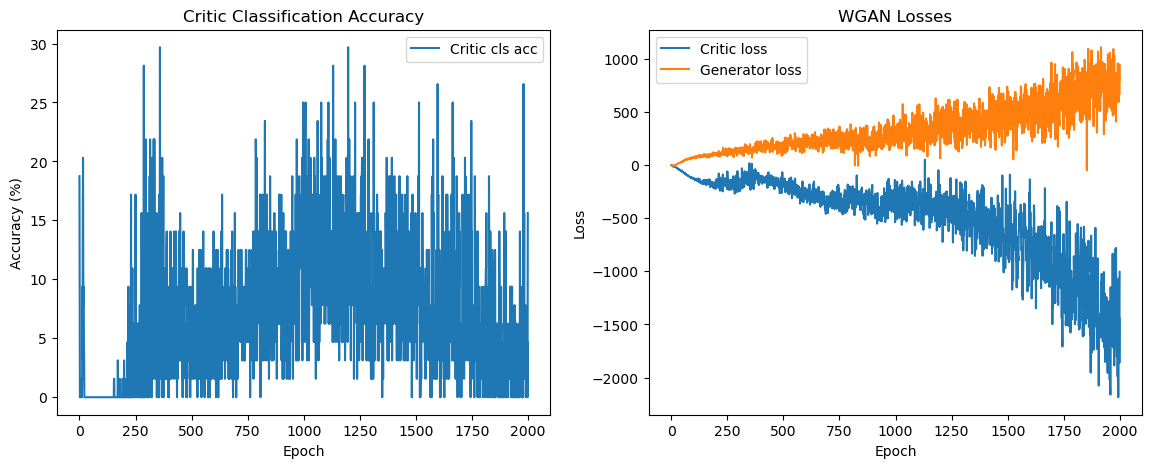

In [30]:
gan.plot_training_history()

12/12 [==============================] - 0s 10ms/step
Average Precision: 65.38%
Overall accuracy: 70.60%
Classification Report:
               precision    recall  f1-score   support

           0       0.09      0.11      0.10         9
           1       0.77      0.83      0.80       132
           2       0.62      0.88      0.73        92
           3       0.81      0.50      0.62       131

    accuracy                           0.71       364
   macro avg       0.57      0.58      0.56       364
weighted avg       0.73      0.71      0.70       364



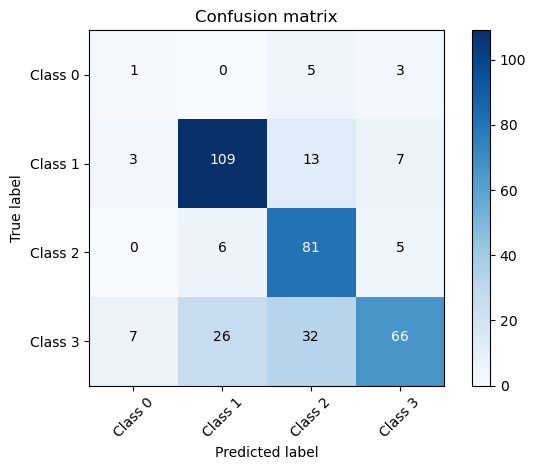

In [32]:
gan.predict(X_test,y_test)

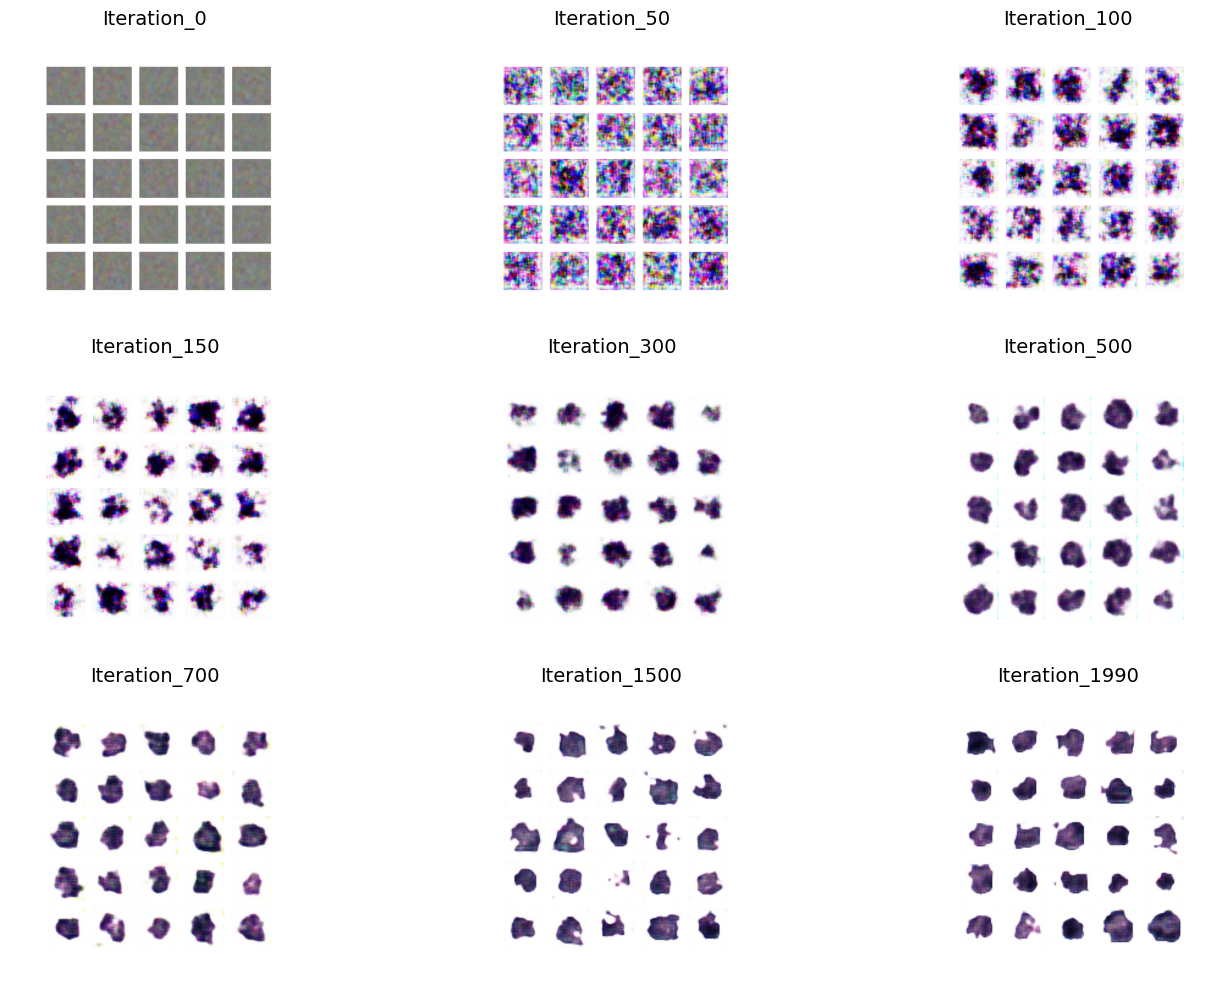

In [34]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Replace the path with your image file's path
files = [0, 50, 100, 150,300, 500,700, 1500, 1990]

# Create a figure with subplots
fig, axes = plt.subplots(3, 3, figsize=(15, 10))  # Adjust the grid size as needed
axes = axes.ravel()  # Flatten the axes array for easy indexing

# Loop through the files and plot each image
for i, file in enumerate(files):
    # Read the image
    img = mpimg.imread(f'wgan_generated_output/epoch_{file}.png')
    
    # Plot the image
    axes[i].imshow(img)
    axes[i].set_title(f'Iteration_{file}', fontsize=14)
    axes[i].axis('off')  # Optional: hides the axes

# Hide any unused subplots
for j in range(i+1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()  # Adjust the layout to prevent overlap
plt.show()
